In [1]:
import gymnasium as gym
import numpy as np
import math
import os
import configparser
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt
from sb3_contrib.common.maskable.utils import get_action_masks



In [2]:
from src.hpc_env import HPCenv
from src.validation import Validation
from src.baseline import PercentileBaseline
from src.utils import mask_fn, get_config_as_dict
from src.carbon_intensity import CarbonIntensity

In [3]:
# Use interactive widget backend if ipympl is available; otherwise fallback to inline
try:
    import ipympl  # noqa: F401
    get_ipython().run_line_magic('matplotlib', 'widget')
except Exception:
    get_ipython().run_line_magic('matplotlib', 'inline')
    print('ipympl not available; using inline Matplotlib backend. Install with `pip install ipympl` for widgets.')


ipympl not available; using inline Matplotlib backend. Install with `pip install ipympl` for widgets.


In [ ]:

# Load config with explicit path and typed parsing
config = configparser.ConfigParser()
config_path = os.path.join(os.getcwd(), 'config_file', 'config.ini')
config.read(config_path)

['/Users/mikkeldahl/green-hpc-scheduler/config_file/config.ini']

## Model validation

In [5]:
val = Validation()
val.load_dir("results/CI_B16384_RC_LR-00000_ETA0.0_C-None_Lu")
processed_stats, raw_stats = val.run_baselines(n_eval_episodes=1, mode="validation")

run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980
run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980
run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980
run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980
run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980
Executing baseline:  FCFS Baseline
Episode  0
Executing baseline:  10-percentile Baseline
Episode  0
cutoff:  -1.011053028793765
cutoff:  -1.011053028793765
cutoff:  -1.011053028793765
cutoff:  -1.011053028793765
cutoff:

In [6]:
processed_stats

{'FCFS Baseline': {'Validation Reward': 18.841868820294778,
  'Avg Wait': 6241.402740396379,
  'Max Wait': 533605.0,
  'Avg Response': 10793.021531685834,
  'Avg Slowdown': 177.4515107448421,
  'Episode Duration': 7837750.0,
  'Carbon Emissions': 28091754.682081796,
  'Weighted Carbon Emissions': -28091754.682081796,
  'System Utilization': 0.5823901774464929,
  'Action Analysis': {'Total Actions': 23851,
   'Schedule Action Percentage': 34.271099744245525,
   'Fixed Delay Percentage': 0.1383589786591757,
   'Wait Delay Percentage': 65.5905412770953,
   'Fixed Delays': {'300s': 33},
   'Wait for Jobs': {'1 jobs': 15644}}},
 '10-percentile Baseline': {'Validation Reward': -171.87773079709842,
  'Avg Wait': 8736924.74724737,
  'Max Wait': 14737105.0,
  'Avg Response': 8741476.36603866,
  'Avg Slowdown': 402867.4249347136,
  'Episode Duration': 21805354.0,
  'Carbon Emissions': 19482574.3391975,
  'Weighted Carbon Emissions': -19482574.3391975,
  'System Utilization': 0.209335221674514,
 

In [7]:
val.load_dir("results/CI_B4096_RC_LR-00001_ETA0.0_C-None_Lu")
val.render_timeseries_plot(raw_stats['25-percentile Baseline']['action_traces'])

FileNotFoundError: Configuration file not found at '/Users/mikkeldahl/green-hpc-scheduler/results/CI_B4096_RC_LR-00001_ETA0.0_C-None_Lu/config.json'. Please ensure it exists.

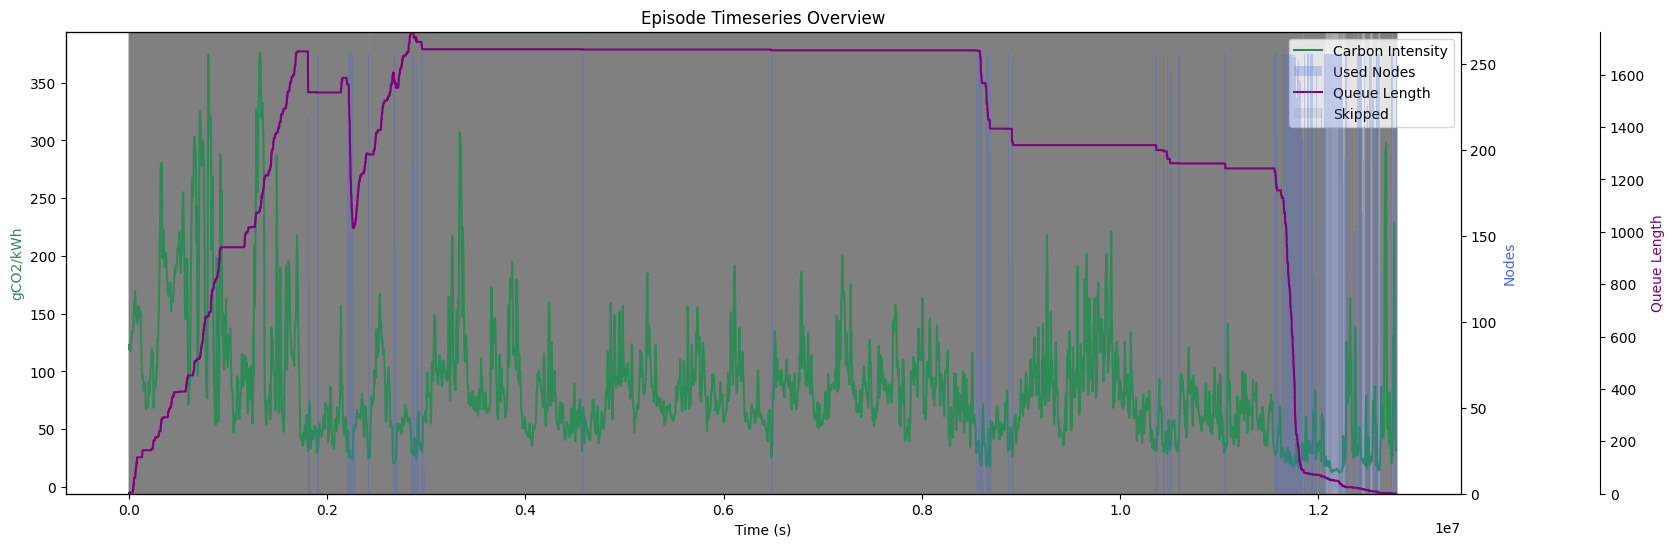

('renderings/timeseries.png', <Figure size 1800x600 with 3 Axes>)

In [ ]:
val.load_dir("results/CI_B4096_RC_LR-00001_ETA0.0_C-None_Lu")
val.render_timeseries_plot(raw_stats['10-percentile Baseline']['action_traces'])

In [ ]:
processed_stats

{'FCFS Baseline': {'Avg Wait': np.float64(4552.721755725191),
  'Max Wait': np.float64(4552.721755725191),
  'Avg Response': np.float64(8991.09351145038),
  'Avg Slowdown': np.float64(127.53263829568381),
  'Carbon Emissions': np.float64(9349788.624349324),
  'Weighted Carbon Emissions': np.float64(-9349788.624349324),
  'System Utilization': np.float64(0.45633334506960394),
  'Action Analysis': {'Total Actions': 10603,
   'Schedule Action Percentage': 24.70998773931906,
   'Fixed Delay Percentage': 24.38932377628973,
   'Wait Delay Percentage': 50.90068848439121,
   'Fixed Delays': {'300s': 2586},
   'Wait for Jobs': {'1 jobs': 5397}}},
 '10-percentile Baseline': {'Avg Wait': np.float64(6431648.060305344),
  'Max Wait': np.float64(6431648.060305344),
  'Avg Response': np.float64(6436086.432061069),
  'Avg Slowdown': np.float64(289532.42415359936),
  'Carbon Emissions': np.float64(6740089.32170967),
  'Weighted Carbon Emissions': np.float64(-6740089.32170967),
  'System Utilization': n

In [ ]:
val = Validation()
val.load_dir("results/CI_B16384_RC_LR-00000_ETA0.0_C-None_Lu")
processed_stats, raw_stats  = val.validate_policy(n_eval_episodes=1, checkpoints=["seed_1_131072_steps.zip"], mode="validation")

run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980
step:  0 reward:  0.0
step:  1 reward:  0.0
step:  2 reward:  0.0
step:  3 reward:  0.0
step:  4 reward:  0.0
step:  5 reward:  0.0
step:  6 reward:  0.0
step:  7 reward:  0.0
step:  8 reward:  0.0
step:  9 reward:  0.0
step:  10 reward:  0.0
step:  11 reward:  0.0
step:  12 reward:  0.0
step:  13 reward:  0.0
step:  14 reward:  0.06779326937871444
step:  15 reward:  0.0
step:  16 reward:  0.0
step:  17 reward:  0.07121251167805182
step:  18 reward:  0.0
step:  19 reward:  0.0
step:  20 reward:  0.0
step:  21 reward:  0.0
step:  22 reward:  0.0
step:  23 reward:  0.0
step:  24 reward:  0.0
step:  25 reward:  0.0
step:  26 reward:  0.0
step:  27 reward:  0.0
step:  28 reward:  0.0
step:  29 reward:  0.0
step:  30 reward:  0.0
step:  31 reward:  0.0
step:  32 reward:  0.10734472384617497
step:  33 reward:  0.0
step:  34 reward:  0.0
s

In [ ]:
processed_stats

{'seed_1_131072_steps.zip': {'Validation Reward': -44.632743262569754,
  'Avg Wait': 983630.4217557252,
  'Max Wait': 4005308.0,
  'Avg Response': 988068.7935114504,
  'Avg Slowdown': 45393.20025981545,
  'Episode Duration': 4063583.0,
  'Carbon Emissions': 10237454.860194542,
  'Weighted Carbon Emissions': -10237454.860194542,
  'System Utilization': 0.33330205449230393,
  'Action Analysis': {'Total Actions': 8827,
   'Schedule Action Percentage': 29.68165854763793,
   'Fixed Delay Percentage': 42.72119632944375,
   'Wait Delay Percentage': 27.59714512291832,
   'Fixed Delays': {'300s': 402, '3600s': 3329, '86400s': 40},
   'Wait for Jobs': {'3 jobs': 2157, '2 jobs': 91, '1 jobs': 188}}}}

In [ ]:
{'seed_1_1000000_steps.zip': {'Avg Wait': np.float64(38872.987404580155),
  'Max Wait': np.float64(38872.987404580155),
  'Avg Response': np.float64(43311.35916030534),
  'Avg Slowdown': np.float64(1489.8845163117558),
  'Carbon Emissions': np.float64(9150966.558763998),
  'Weighted Carbon Emissions': np.float64(-9150966.558763998),
  'System Utilization': np.float64(0.4422815509172179),
  'Action Analysis': {'Total Actions': 8939,
   'Schedule Action Percentage': 29.309766193086475,
   'Fixed Delay Percentage': 40.709251594138046,
   'Wait Delay Percentage': 29.980982212775476,
   'Fixed Delays': {'1800s': 1002,
    '3600s': 10,
    '1200s': 2147,
    '300s': 119,
    '3000s': 357,
    '600s': 2,
    '2400s': 2},
   'Wait for Jobs': {'3 jobs': 2647, '1 jobs': 27, '2 jobs': 6}}},
 'seed_1_1500000_steps.zip': {'Avg Wait': np.float64(63645.93282442748),
  'Max Wait': np.float64(63645.93282442748),
  'Avg Response': np.float64(68084.30458015268),
  'Avg Slowdown': np.float64(2765.9974486387514),
  'Carbon Emissions': np.float64(9035064.591793105),
  'Weighted Carbon Emissions': np.float64(-9035064.591793105),
  'System Utilization': np.float64(0.44737427430532156),
  'Action Analysis': {'Total Actions': 9789,
   'Schedule Action Percentage': 26.76473592808254,
   'Fixed Delay Percentage': 51.28205128205128,
   'Wait Delay Percentage': 21.953212789866175,
   'Fixed Delays': {'3000s': 83,
    '1800s': 49,
    '3600s': 816,
    '2400s': 90,
    '300s': 2257,
    '600s': 402,
    '1200s': 1323},
   'Wait for Jobs': {'2 jobs': 182, '1 jobs': 1595, '3 jobs': 372}}},
 'seed_1_2000000_steps.zip': {'Avg Wait': np.float64(904152.520610687),
  'Max Wait': np.float64(904152.520610687),
  'Avg Response': np.float64(908590.8923664122),
  'Avg Slowdown': np.float64(40812.89514256688),
  'Carbon Emissions': np.float64(10103012.032682786),
  'Weighted Carbon Emissions': np.float64(-10103012.032682786),
  'System Utilization': np.float64(0.3339073236219857),
  'Action Analysis': {'Total Actions': 11589,
   'Schedule Action Percentage': 22.607645180774874,
   'Fixed Delay Percentage': 74.62248684096988,
   'Wait Delay Percentage': 2.769867978255242,
   'Fixed Delays': {'2400s': 93,
    '1800s': 86,
    '3000s': 6,
    '300s': 42,
    '600s': 5190,
    '1200s': 3228,
    '3600s': 3},
   'Wait for Jobs': {'3 jobs': 268, '2 jobs': 53}}},
 'seed_1_2500000_steps.zip': {'Avg Wait': np.float64(117206.09847328244),
  'Max Wait': np.float64(117206.09847328244),
  'Avg Response': np.float64(121644.47022900764),
  'Avg Slowdown': np.float64(4927.1117421583385),
  'Carbon Emissions': np.float64(9160477.174398202),
  'Weighted Carbon Emissions': np.float64(-9160477.174398202),
  'System Utilization': np.float64(0.44349924244309563),
  'Action Analysis': {'Total Actions': 9793,
   'Schedule Action Percentage': 26.753803737363423,
   'Fixed Delay Percentage': 51.39385275196568,
   'Wait Delay Percentage': 21.852343510670888,
   'Fixed Delays': {'3000s': 13, '300s': 62, '600s': 1556, '1200s': 3402},
   'Wait for Jobs': {'1 jobs': 4, '2 jobs': 37, '3 jobs': 2099}}},
 'seed_1_3000000_steps.zip': {'Avg Wait': np.float64(43254.7213740458),
  'Max Wait': np.float64(43254.7213740458),
  'Avg Response': np.float64(47693.09312977099),
  'Avg Slowdown': np.float64(1760.7702863722236),
  'Carbon Emissions': np.float64(9498929.547369653),
  'Weighted Carbon Emissions': np.float64(-9498929.547369653),
  'System Utilization': np.float64(0.44742880916396194),
  'Action Analysis': {'Total Actions': 11274,
   'Schedule Action Percentage': 23.239311690615576,
   'Fixed Delay Percentage': 73.62072024126309,
   'Wait Delay Percentage': 3.139968068121341,
   'Fixed Delays': {'1200s': 1071,
    '300s': 309,
    '3000s': 11,
    '600s': 6896,
    '3600s': 8,
    '2400s': 4,
    '1800s': 1},
   'Wait for Jobs': {'2 jobs': 196, '3 jobs': 158}}},
 'seed_1_500000_steps.zip': {'Avg Wait': np.float64(16607.18969465649),
  'Max Wait': np.float64(16607.18969465649),
  'Avg Response': np.float64(21045.56145038168),
  'Avg Slowdown': np.float64(453.7653807179799),
  'Carbon Emissions': np.float64(9329014.728126928),
  'Weighted Carbon Emissions': np.float64(-9329014.728126928),
  'System Utilization': np.float64(0.45039880845887453),
  'Action Analysis': {'Total Actions': 9548,
   'Schedule Action Percentage': 27.440301633850023,
   'Fixed Delay Percentage': 70.70590699622957,
   'Wait Delay Percentage': 1.853791369920402,
   'Fixed Delays': {'600s': 2249,
    '300s': 177,
    '1200s': 1537,
    '3000s': 2615,
    '1800s': 162,
    '2400s': 5,
    '3600s': 6},
   'Wait for Jobs': {'1 jobs': 166, '3 jobs': 11}}}}

In [ ]:
val.render_timeseries_plot(raw_stats['seed_1_1500000_steps']['action_traces'])

KeyError: 'seed_1_1500000_steps'

In [ ]:
val = Validation()
val.load_dir("results/clean-microwave-130: carbon convergence")
processed_stats, raw_stats  = val.validate_policy(n_eval_episodes=1, checkpoints=None, mode="validation")

run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980
-7860.0
-7860.0


KeyboardInterrupt: 

In [ ]:
processed_stats

{'seed_1_1000000_steps.zip': {'Validation Reward': -7860.0,
  'Avg Wait': 2299596.5797709925,
  'Max Wait': 3487669.0,
  'Avg Response': 2304034.9515267177,
  'Avg Slowdown': 106365.29041358021,
  'Episode Duration': 4811328.0,
  'Carbon Emissions': 9143926.474562304,
  'Weighted Carbon Emissions': -9143926.474562304,
  'System Utilization': 0.28150243810025005,
  'Action Analysis': {'Total Actions': 17733,
   'Schedule Action Percentage': 14.77471381040997,
   'Fixed Delay Percentage': 82.47899396605199,
   'Wait Delay Percentage': 2.7462922235380365,
   'Fixed Delays': {'86400s': 698, '300s': 13901, '3600s': 27},
   'Wait for Jobs': {'1 jobs': 487}}},
 'seed_1_1500000_steps.zip': {'Validation Reward': -7860.0,
  'Avg Wait': 2374544.632061069,
  'Max Wait': 4979726.0,
  'Avg Response': 2378983.0038167937,
  'Avg Slowdown': 109811.26797626077,
  'Episode Duration': 5048081.0,
  'Carbon Emissions': 9025913.859149622,
  'Weighted Carbon Emissions': -9025913.859149622,
  'System Utilizati